In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [4]:
obs = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])

obs['month'] = obs['date_first_symptoms'].dt.month
obs['year'] = obs['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

cases_2024 = obs[obs['year'] == 2024].groupby(['region', 'city_residency']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
cases_2024['dengue_inc'] = cases_2024['n_cases'] / cases_2024['population'] * 100000
cases_2024['log_cases'] = np.log10(cases_2024['n_cases'] + 1)

gdf = gpd.read_file('~/shapefiles/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

cases_2024 = gdf.set_index(['city_name']).join(cases_2024.set_index('city_residency')[['dengue_inc', 'log_cases', 'n_cases']])

/tmp/ipykernel_2523/2233815055.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])


beta0 (Pr_0priorinf): 1.496  (95% CI -1456360.554 to 1269751.135)
beta1 (Pr_1priorinf): 2.985  (95% CI -1456359.917 to 1269754.315)


/tmp/ipykernel_2523/1838006499.py:176: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf[gdf['city_name'] == city_name].centroid
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


BA_ILHEUS 0.437911612 0.34722486139


/tmp/ipykernel_2523/1838006499.py:176: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf[gdf['city_name'] == city_name].centroid
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


SC_JOINVILLE 0.180376095084 0.53135905496


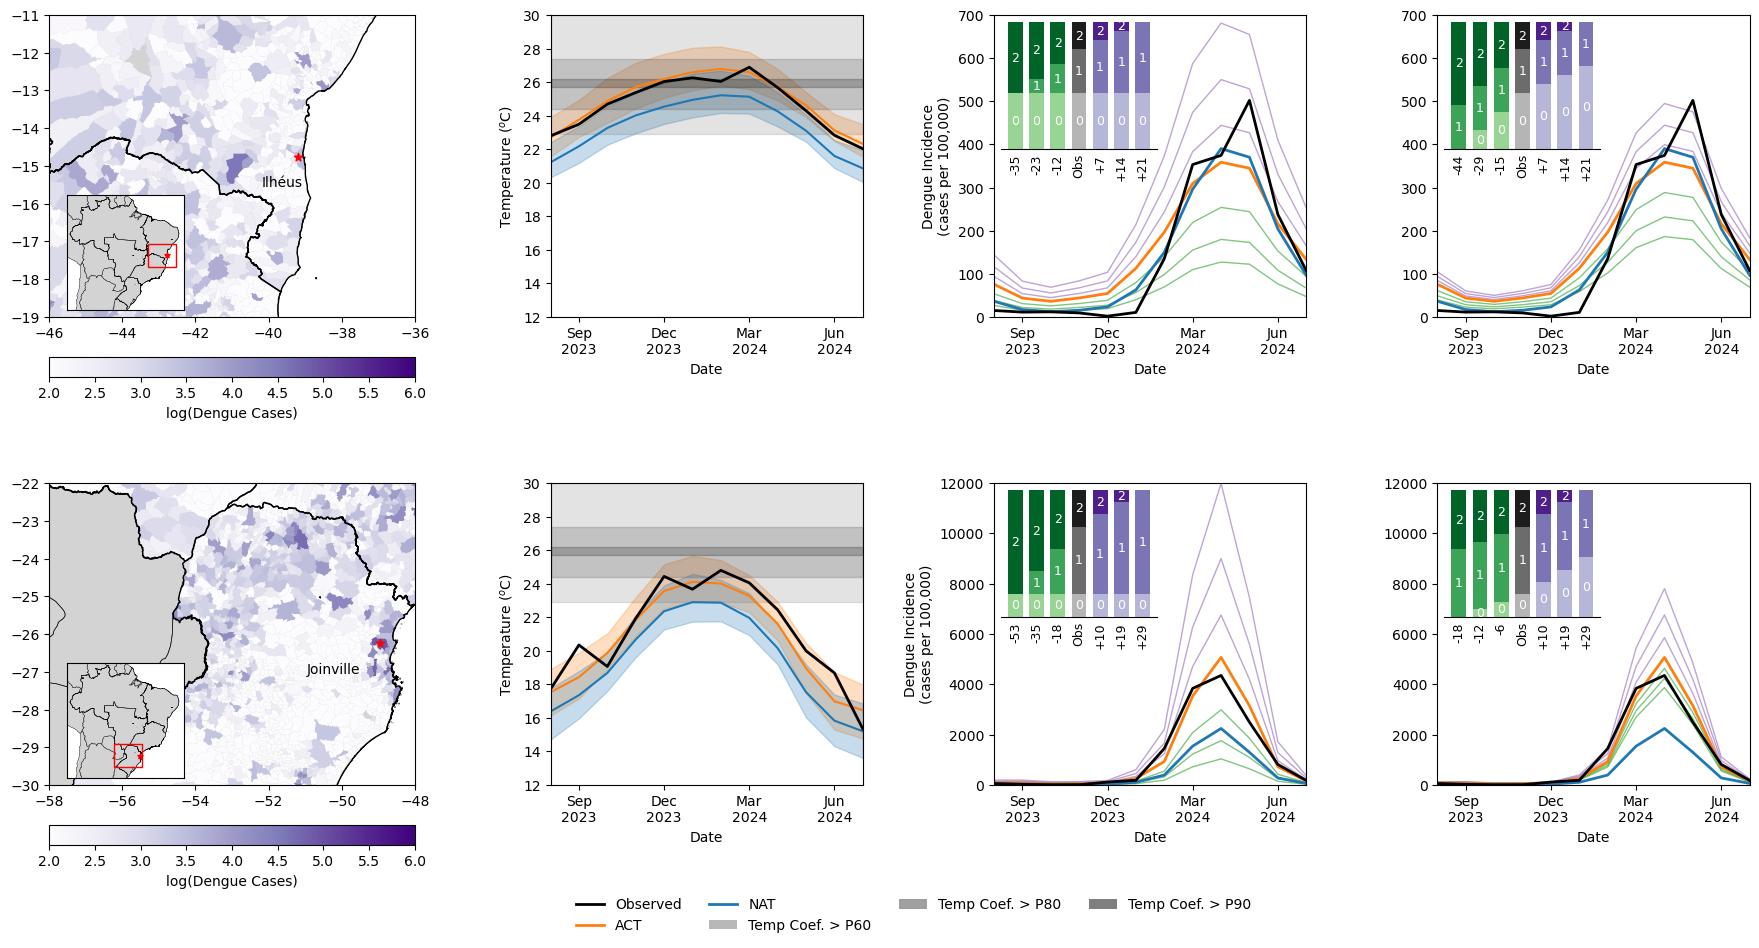

In [5]:
region = gpd.read_file('~/shapefiles/BR_UF_2022/BR_UF_2022.shp')
world = gpd.read_file('~/shapefiles/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp')

# ---------------------------------------------------------------------------
# Load the flagship model's bootstrapped Pr_0priorinf/Pr_1priorinf
# coefficients and take the median as the point-estimate rescaling factor
# (the same bootstrap file used throughout this repo's immunity work).
# ---------------------------------------------------------------------------
flagship_coefs = pd.read_csv(
    'data/coefficients/Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity_coef_state_blockboot1000.csv'
)

beta0 = flagship_coefs['Pr_0priorinf'].median()
beta1 = flagship_coefs['Pr_1priorinf'].median()
beta0_ci = flagship_coefs['Pr_0priorinf'].quantile([0.025, 0.975]).values
beta1_ci = flagship_coefs['Pr_1priorinf'].quantile([0.025, 0.975]).values

print(f"beta0 (Pr_0priorinf): {beta0:.3f}  (95% CI {beta0_ci[0]:.3f} to {beta0_ci[1]:.3f})")
print(f"beta1 (Pr_1priorinf): {beta1:.3f}  (95% CI {beta1_ci[0]:.3f} to {beta1_ci[1]:.3f})")

TARGET_CITIES = ['SC_JOINVILLE', 'BA_ILHEUS']

act_grid = pd.read_csv('data/sensitivity-cities-immunity/act_flagship_immunity_grid_input.csv',
                       parse_dates=['date_first_symptoms'])
nat_grid = pd.read_csv('data/sensitivity-cities-immunity/nat_flagship_immunity_grid_input.csv',
                       parse_dates=['date_first_symptoms'])

act_grid = act_grid[act_grid['city_residency'].isin(TARGET_CITIES)].copy()
nat_grid = nat_grid[nat_grid['city_residency'].isin(TARGET_CITIES)].copy()

# Dissolve the state-level shapefile into the 5 macro-regions (NM_REGIAO has
# trailing "\n" on some values, e.g. 'Nordeste\n' vs 'Norte' — strip first or
# the dissolve splits them into separate groups).
region_macro = region.copy()
region_macro['NM_REGIAO'] = region_macro['NM_REGIAO'].str.strip()
region_macro = region_macro.dissolve(by='NM_REGIAO').reset_index()

# Only 3 swept levels below observed and 3 above, so the fan of lines and the
# immunity bars line up 1:1.
N_LEVELS = 3


def sweep_axis_around(observed_value, fixed_value, n_levels=N_LEVELS):
    below = np.linspace(0, observed_value, n_levels + 1)[:-1]
    above = np.linspace(observed_value, 1 - fixed_value, n_levels + 1)[1:]
    return np.concatenate([below, above])


def sweep_predicted_incidence(df, fixed_value, sweep_axis, vary):
    lines = {}
    for v in sweep_axis:
        target_pr0, target_pr1 = (fixed_value, v) if vary == 'pr1' else (v, fixed_value)
        multiplier = np.exp(
            beta0 * (target_pr0 - df['Pr_0priorinf']) +
            beta1 * (target_pr1 - df['Pr_1priorinf'])
        )
        pred = df['predicted_incidence'] * multiplier
        lines[v] = pred.groupby(df['date_first_symptoms']).median()
    return lines


def plot_sweep(ax, lines, observed_value, obs_incidence, act_median, nat_median, annotate=False):
    items = sorted(lines.items())
    for v, series in items:
        if np.isclose(v, observed_value):
            continue
        color = 'C2' if v < observed_value else 'C4'
        series.plot(ax=ax, color=color, lw=1, alpha=0.6)
        if annotate:
            delta_pp = (v - observed_value) * 100
            ax.annotate(
                f'{delta_pp:+.0f}pp',
                xy=(series.index[-1], series.iloc[-1]),
                xytext=(3, 0), textcoords='offset points',
                fontsize=7, color=color, va='center', annotation_clip=False,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7)
            )
    act_median.plot(ax=ax, color='C1', lw=2)
    nat_median.plot(ax=ax, color='C0', lw=2)
    obs_incidence.plot(ax=ax, color='k', lw=2)


def plot_immunity_bars(ax, fixed_value, sweep_axis, observed_value, vary):
    all_vals = sorted(list(sweep_axis) + [observed_value])
    labels, pr_rows = [], []
    for v in all_vals:
        pr0, pr1 = (fixed_value, v) if vary == 'pr1' else (v, fixed_value)
        pr2 = 1 - pr0 - pr1
        pr_rows.append((v, pr0, pr1, pr2))
        labels.append('Obs' if np.isclose(v, observed_value) else f'{(v - observed_value) * 100:+.0f}')

    x = np.arange(len(all_vals))
    shade_levels = [0.4, 0.65, 0.9]  # light -> dark, for the 3 stacked segments

    for i, (v, pr0, pr1, pr2) in enumerate(pr_rows):
        if np.isclose(v, observed_value):
            cmap = plt.get_cmap('Greys')
        elif v < observed_value:
            cmap = plt.get_cmap('Greens')
        else:
            cmap = plt.get_cmap('Purples')
        colors = [cmap(s) for s in shade_levels]

        bottom = 0
        for seg_val, seg_label, color in zip((pr0, pr1, pr2), ('0', '1', '2'), colors):
            ax.bar(i, seg_val, bottom=bottom, color=color, width=0.7)
            if seg_val > 0.06:
                ax.text(i, bottom + seg_val / 2, seg_label, ha='center', va='center',
                         fontsize=9, color='white')
            bottom += seg_val

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=90)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.patch.set_alpha(0.85)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='x', length=0)


CITY_CONFIG = {
    'BA_ILHEUS': {
        'label': 'Ilhéus',
        'map_xlim': (-46, -36), 'map_ylim': (-19, -11),
        'label_offset': (-1, -0.8),
        'incidence_ylim': [0, 700]
    },
    'SC_JOINVILLE': {
        'label': 'Joinville',
        'map_xlim': (-58, -48), 'map_ylim': (-30, -22),
        'label_offset': (-2, -0.8),
        'incidence_ylim': [0, 12000]
    },
}
ROW_CITIES = ['BA_ILHEUS', 'SC_JOINVILLE']

dates = pd.date_range('2023-09-01', '2024-07-01', freq='3MS')

BRAZIL_XLIM = (-75, -33)
BRAZIL_YLIM = (-34, 6)


def set_xticks(ax):
    ax.set_xticks(dates)
    ax.set_xticklabels([date.strftime('%b\n%Y') for date in dates])
    ax.xaxis.set_minor_locator(plt.NullLocator())


fig = plt.figure(figsize=(22, 10))
gs = GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.4, width_ratios=[1.2, 1, 1, 1])

sm = cm.ScalarMappable(cmap='Purples', norm=mcolors.Normalize(vmin=2, vmax=6))
sm.set_array([])

for row, city_name in enumerate(ROW_CITIES):
    cfg = CITY_CONFIG[city_name]
    ax_map, ax_temp, ax_sweep1, ax_sweep0 = (fig.add_subplot(gs[row, c]) for c in range(4))

    act_c = act_grid[act_grid['city_residency'] == city_name]
    nat_c = nat_grid[nat_grid['city_residency'] == city_name]

    obs_vals = act_c[act_c['ensemble_member'] == 0].set_index('date_first_symptoms')['actual_incidence']
    act_median = act_c.groupby('date_first_symptoms')['predicted_incidence'].median()
    nat_median = nat_c.groupby('date_first_symptoms')['predicted_incidence'].median()

    imm_own = act_c.groupby('date_first_symptoms')[['Pr_0priorinf', 'Pr_1priorinf']].mean().iloc[-1]
    own_pr0, own_pr1 = imm_own['Pr_0priorinf'], imm_own['Pr_1priorinf']
    own_pr2 = 1 - own_pr0 - own_pr1

    # --- Column 1: Map ---
    ax = ax_map
    world.plot(ax=ax, color='lightgrey', edgecolor='black', lw=0.5)
    cases_2024.plot(ax=ax, column='log_cases', vmin=2, vmax=6, cmap='Purples', legend=False)
    region_macro.plot(ax=ax, color='none', edgecolor='black', lw=1)
    centroid = gdf[gdf['city_name'] == city_name].centroid
    ax.scatter([centroid.x], [centroid.y], color='red', marker='*')
    ax.text(centroid.x.iloc[0] + cfg['label_offset'][0], centroid.y.iloc[0] + cfg['label_offset'][1], cfg['label'])
    ax.set_xlim(cfg['map_xlim'])
    ax.set_ylim(cfg['map_ylim'])

    # --- Inset: whole-Brazil locator map, red box marking the zoomed region ---
    axins = inset_axes(ax, width='38%', height='38%', loc='lower left', borderpad=0.5)
    world.plot(ax=axins, color='lightgrey', edgecolor='black', lw=0.3)
    region_macro.plot(ax=axins, color='none', edgecolor='black', lw=0.3)
    axins.scatter([centroid.x], [centroid.y], color='red', marker='*', s=15)
    zoom_box = Rectangle(
        (cfg['map_xlim'][0], cfg['map_ylim'][0]),
        cfg['map_xlim'][1] - cfg['map_xlim'][0],
        cfg['map_ylim'][1] - cfg['map_ylim'][0],
        fill=False, edgecolor='red', lw=1
    )
    axins.add_patch(zoom_box)
    axins.set_xlim(BRAZIL_XLIM)
    axins.set_ylim(BRAZIL_YLIM)
    axins.set_xticks([])
    axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    pos = ax.get_position()
    cax = fig.add_axes([pos.x0, pos.y0 - 0.06, pos.width, 0.02])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('log(Dengue Cases)')

    # --- Column 2: Temperature (ACT vs. NAT ensemble) ---
    ax = ax_temp
    temp_act_q = act_c.pivot_table(
        index='date_first_symptoms', columns='ensemble_member', values='mean_2m_air_temp_degree1'
    ).quantile([0.025, 0.5, 0.975], axis=1).transpose()
    temp_nat_q = nat_c.pivot_table(
        index='date_first_symptoms', columns='ensemble_member', values='mean_2m_air_temp_degree1'
    ).quantile([0.025, 0.5, 0.975], axis=1).transpose()

    for q, color in [(temp_act_q, 'C1'), (temp_nat_q, 'C0')]:
        q[0.500].plot(ax=ax, color=color)
        ax.fill_between(q.index, q[0.025], q[0.975], alpha=0.25, color=color)

    obs_temp = obs[(obs['city_residency'] == city_name) & (obs['date_first_symptoms'] >= '2023-08-01')]
    obs_temp.set_index('date_first_symptoms').plot(y='mean_2m_air_temp_degree1', color='k', lw=2, ax=ax, legend=False)

    spans = [
        [22.9, 30, '#737373'],
        [24.4, 27.4, '#404040'],
        [25.7, 26.2, '#000000'],
    ]
    for lo, hi, color in spans:
        ax.axhspan(lo, hi, color=color, alpha=0.2)

    ax.set_xlabel('Date')
    ax.set_ylabel(r'Temperature ($^o$C)')
    ax.set_ylim(12, 30)
    set_xticks(ax)

    # --- Column 3: sweep infected-once, naive fixed at observed ---
    print(city_name, own_pr0, own_pr1)
    
    ax = ax_sweep1
    pr1_axis = sweep_axis_around(own_pr1, own_pr0)
    lines_pr1 = sweep_predicted_incidence(act_c, own_pr0, pr1_axis, vary='pr1')
    plot_sweep(ax, lines_pr1, own_pr1, obs_vals, act_median, nat_median, annotate=False)

    bar_ax1 = inset_axes(ax, width='50%', height='42%', loc='upper left', borderpad=0.5)
    plot_immunity_bars(bar_ax1, own_pr0, pr1_axis, own_pr1, vary='pr1')

    ax.set_xlabel('Date')
    ax.set_ylabel('Dengue Incidence\n(cases per 100,000)')
    #ax.set_title('Infected once swept')
    ax.set_ylim(cfg['incidence_ylim'])
    set_xticks(ax)

    # --- Column 4: sweep never-infected, infected-once fixed at observed ---
    ax = ax_sweep0
    pr0_axis = sweep_axis_around(own_pr0, own_pr1)
    lines_pr0 = sweep_predicted_incidence(act_c, own_pr1, pr0_axis, vary='pr0')
    plot_sweep(ax, lines_pr0, own_pr0, obs_vals, act_median, nat_median, annotate=False)

    bar_ax0 = inset_axes(ax, width='50%', height='42%', loc='upper left', borderpad=0.5)
    plot_immunity_bars(bar_ax0, own_pr1, pr0_axis, own_pr0, vary='pr0')

    ax.set_xlabel('Date')
    #ax.set_title('Never-infected swept')
    ax.set_ylim(cfg['incidence_ylim'])
    set_xticks(ax)

legend_elements = [
    Line2D([0], [0], color='k', lw=2, label='Observed'),
    Line2D([0], [0], color='C1', lw=2, label='ACT'),
    Line2D([0], [0], color='C0', lw=2, label='NAT'),
    Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'),
    Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'),
    Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.52, 0.01), frameon=False, ncols=4)

#plt.savefig('img/figure4_immunity_swap_timeseries.png', bbox_inches='tight', dpi=300)
plt.show()